# Analysis — Many Particles

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
np.seterr('warn')

from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, get_xf_yf_fund, get_mean_amp_and_phase, get_fft, time_domain_visual_verification
from snr_aux_functions import get_snr_db, plot_time_and_freq_domain

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [2]:
filenames_all = fetch_data_filenames("./08-06-26/")

In [3]:
# filenames_all = fetch_data_filenames("./23-05-26")
exc_data_npy = [
    extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all 
    if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("exc_laser" in data_path_npy)
    ]

In [4]:
#Populate particle list

num_particles = 5
p_list = [
    {
        "p_label": p_id+1,
        "p_data": [
            extract_data_info_from_path(p_data_path)
            for p_data_path in filenames_all
            if (f"p{p_id+1}_lum" in p_data_path) and ("step" in p_data_path) and (".npy" in p_data_path)
        ]
    }
    for p_id in range(num_particles)
]

In [5]:
freq_list = sorted(set([dic["freq"] for dic in exc_data_npy]))
# power_label = sorted(list(range(150, 850, 50)), reverse=True)

# Layout dos subplots de verificação visual
cols = 4
rows = int(np.ceil(len(freq_list) / cols))
    

## Análise — loop sobre N partículas

### Plot all


  Processing particle 1  


IndexError: index 7 is out of bounds for axis 0 with size 7

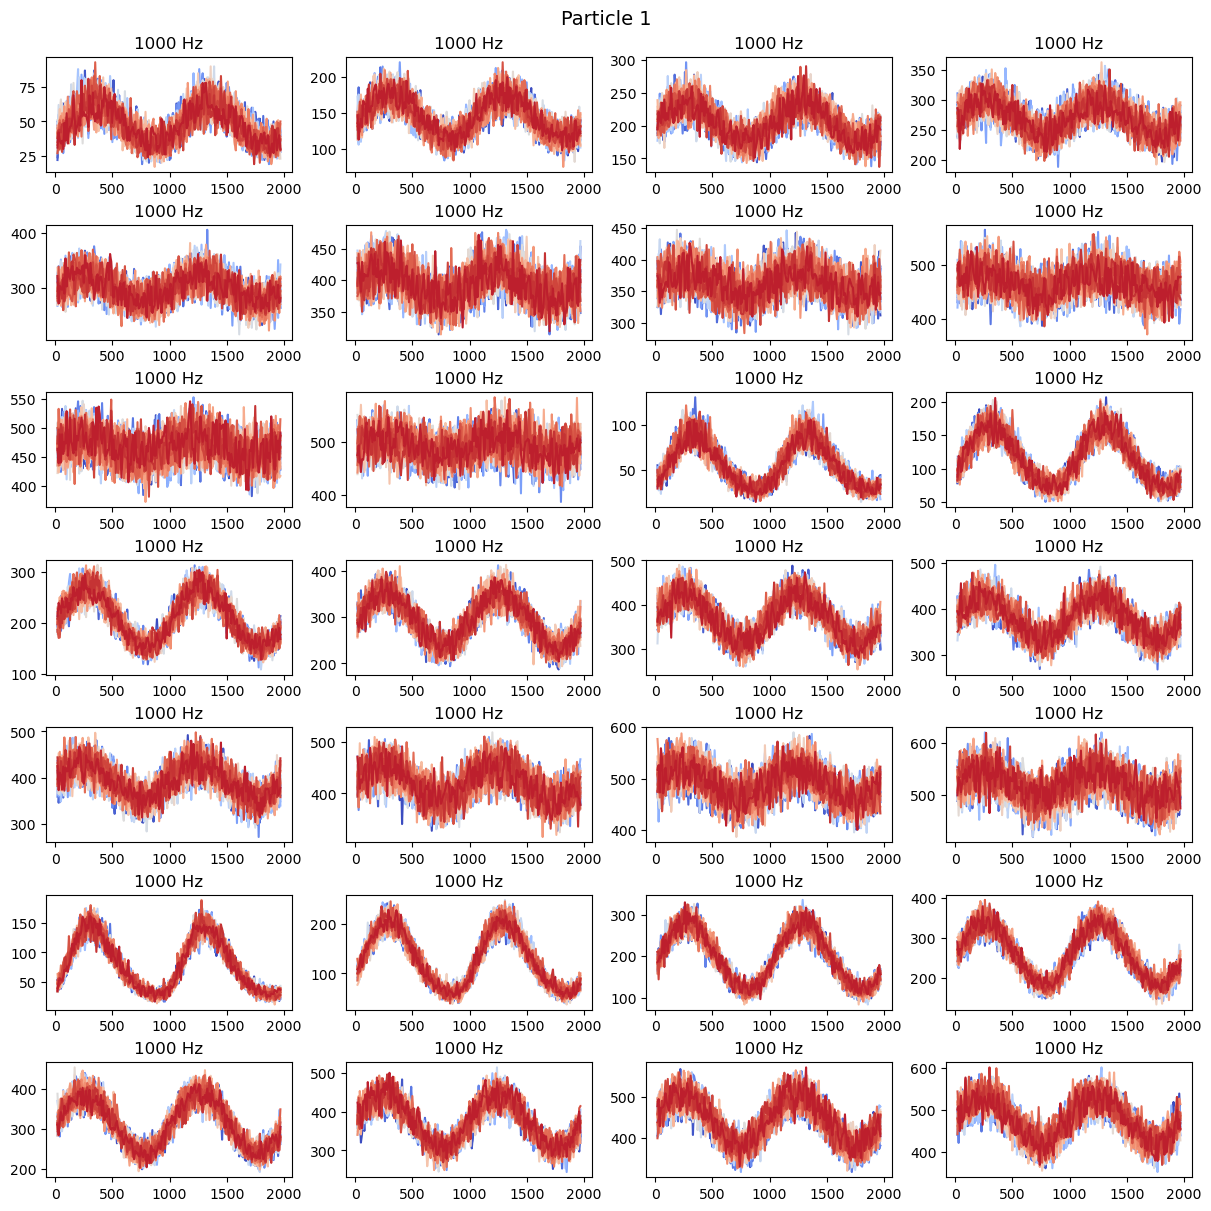

In [6]:
time_domain_visual_verification(p_list, rows=rows, cols=cols)

## Get mean phases and errors

In [ ]:
#Calculate list of phasors for the laser and all measurements
for step in exc_data_npy:
  freq = step["freq"]
  step["fft_amp_list"] = []
  for meas_idx, meas in enumerate(step["data"]):
    _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
    step["fft_amp_list"].append(amp)

In [ ]:
# Get mean phase and error for each particle and each step (freq) 
for step in exc_data_npy:
    freq = step["freq"]
    amp_list = step["fft_amp_list"]
    _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
    step["mean_fft_info"] = [freq, phase, phase_error]

In [ ]:
#Calculate list of phasors for all particles and all measurements
for p in p_list:
  for step in p["p_data"]:
    freq = step["freq"]
    step["fft_amp_list"] = []
    for meas_idx, meas in enumerate(step["data"]):
      _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
      step["fft_amp_list"].append(amp)

In [ ]:
# Get mean phase and error for each particle and each step (freq) 
for p in p_list:
    for step in p["p_data"]:
        freq = step["freq"]
        amp_list = step["fft_amp_list"]
        _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
        step["mean_fft_info"] = [freq, phase, phase_error]

## Comparison — all particles

In [ ]:
def get_error_bar(exc_data, p_list):
    exc_mean_phase = np.array([
            step["mean_fft_info"]
            #[freq, phase, phase_error]
            for step in exc_data
        ])
    error_exc = exc_mean_phase[:,2]
    # print(error_exc)

    for p in p_list:
        # if p["p_label"] !=1: continue
        p_mean_phase = np.array([
            step["mean_fft_info"]
            for step in p["p_data"]
            ])
        
        if (p_mean_phase[:,0]-exc_mean_phase[:,0]).sum() != 0.:
            print("Deu ruim!")
            return None
        else:
            pd_list = np.unwrap(p_mean_phase[:,1]-exc_mean_phase[:,1])
            pd_error = np.hypot(
                p_mean_phase[:,2],
                exc_mean_phase[:,2]
            )

        p["error_bar"] = np.column_stack((p_mean_phase[:,0], pd_list, pd_error))

get_error_bar(exc_data_npy, p_list)

In [ ]:
def plot_phase_difference(particles: list, p_to_skip = [], freqs_to_skip = []):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for p_id, p in enumerate(particles):
        if p["p_label"] in p_to_skip: continue
        color = colors[p_id % len(colors)]
        # p["error_bar"]
        label_added = False
        for idx, error_point in enumerate(p["error_bar"]):
            # Skip frequencies larger than 20kHz
            if (error_point[0] in freqs_to_skip): 
                # print(f"Não foi calculado pra freq: {error_point[0]}Hz")
                continue
            
            current_label = f"Particle {p['p_label']}" if not label_added else None

            plt.errorbar(
                error_point[0],
                error_point[1],
                yerr=error_point[2],
                label=current_label,
                fmt='o',
                capsize=5,
                color=color,
            )
            label_added = True
        # plt.title(f"Particle {p['p_label']}  - phase difference")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Phase diferrence (rad)")
        plt.xscale("log")
    
    if len(particles)>1:
        plt_title = f"{len(particles)} Particles - phase difference" 
    else:
        plt_title = f"{len(particles)} Particle - phase difference" 

    plt.title(plt_title)
    plt.legend()
    plt.show()

plot_phase_difference(p_list, p_to_skip=[], freqs_to_skip=[50000, 70000, 100000])

## Signal-Noise relation

### SNR for fundamental frequency $\omega$ and phase shift error 

In [ ]:
p_idx = 0

snr_list = []

for step_idx, step in enumerate(p_list[p_idx]["p_data"]):
    # if step["freq"] < 10: continue
    # print(f"freq: {step["freq"]}Hz")

    signal = np.array(step["data"])
    # laser_signal = np.array(next(exc["data"] for exc in exc_data_npy if exc["freq"] == step["freq"]))
    
    snr_list.append([
        step["freq"],
        get_snr_db(signal[0,:,0], signal[:,:,1].mean(axis=0)),
    ])

snr_list = np.array(snr_list)


# snr_list
p_idx = 0
for idx, item in enumerate(p_list[p_idx]["error_bar"]):
    # Freq match
    if item[0] == snr_list[idx,0]:
        plt.scatter(snr_list[idx,0], snr_list[idx,1], color="blue")

plt.title("SNR for fundamental frequency $\omega$")
plt.ylabel("SNR (dB)")
plt.xlabel("Frequency (Hz)")
plt.xscale("log")
plt.show()


In [ ]:
p_idx = 0

for idx, item in enumerate(p_list[p_idx]["error_bar"]):
    # Freq match
    if item[0] == snr_list[idx,0]:
        plt.scatter(snr_list[idx,0], item[2], color="blue")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase error (rad)")
plt.xscale("log")
plt.show()

### SNR for $2\omega$

In [ ]:
p_idx = 0
snr_2omega_list = []

for step_idx, step in enumerate(p_list[p_idx]["p_data"]):
    # if step["freq"] != 1 : continue
    # print(f"freq: {step["freq"]}Hz")

    signal = np.array(step["data"])
    # laser_signal = np.array(next(exc["data"] for exc in exc_data_npy if exc["freq"] == step["freq"]))
    
    snr_2omega_list.append([
        step["freq"],
        get_snr_db(signal[0,:,0], signal[:,:,1].mean(axis=0), freq=2),
    ])

snr_2omega_list = np.array(snr_2omega_list)


# snr_list
p_idx = 0
for idx, item in enumerate(p_list[p_idx]["error_bar"]):
    # Freq match
    if item[0] == snr_2omega_list[idx,0]:
        plt.scatter(snr_2omega_list[idx,0], snr_2omega_list[idx,1], color="blue")

# Limiar de 3dB
plt.plot(snr_2omega_list[:,0], 3*np.ones(len(snr_2omega_list[:,0])), "g--", label="3dB")

plt.title("SNR for 2nd harmonic $2\omega$")
plt.ylabel("SNR (dB)")
plt.xlabel("Frequency (Hz)")
plt.xscale("log")
plt.legend()
plt.show()


### SNR for the DC component

In [ ]:
p_idx = 0
snr_dc_list = []

for step_idx, step in enumerate(p_list[p_idx]["p_data"]):
    # if step["freq"] != 1 : continue
    # print(f"freq: {step["freq"]}Hz")

    signal = np.array(step["data"])
    # laser_signal = np.array(next(exc["data"] for exc in exc_data_npy if exc["freq"] == step["freq"]))
    
    snr_dc_list.append([
        step["freq"],
        get_snr_db(signal[0,:,0], signal[:,:,1].mean(axis=0), freq=0),
    ])

snr_dc_list = np.array(snr_dc_list)


# snr_list
p_idx = 0
for idx, item in enumerate(p_list[p_idx]["error_bar"]):
    # Freq match
    if item[0] == snr_dc_list[idx,0]:
        plt.scatter(snr_dc_list[idx,0], snr_dc_list[idx,1], color="blue")


plt.title("SNR for DC component")
plt.ylabel("SNR (dB)")
plt.xlabel("Frequency (Hz)")
plt.xscale("log")
plt.show()


### Amplitudes (Luminescence)

In [ ]:
for p_idx, p in enumerate(p_list):

    # if p_idx in particles_off: continue
    if p_idx != 0: continue
    # cmap = plt.get_cmap("coolwarm")
    # norm = mcolors.Normalize(vmin=0, vmax = (len(p_list)-1) )
    # c_grad = cmap(norm(len(p_list) - p_idx))
    for step_idx, step in enumerate(p["p_data"]):
        if step["freq"] != 10: continue
        # if step["freq"] in freqs_off: continue
        # if step["freq"]
        time = np.array(step["data"])[0,:,0]
        signal = np.array(step["data"])[:,:,1].mean(axis=0)
        plot_time_and_freq_domain(time, signal, signal)
        # plt.scatter(step["freq"], calculate_thd(time, signal, fundamental_freq=step["freq"], num_harmonics=num_harmonics), 
        #             color=c_grad,
        #             )


        

Dado um espectro de potência, a partir de qual harmônico eu posso considerar os harmônicos seguintes como ruído?
Considere um harmônico n, os harmônicos seguintes serão $\{ P_k \} = \{ P(k \omega) \}$, onde $k>n$. 

Daí, consideramos $P(n\omega)$ sinal se $P(n\omega) > \bar{P_k} + 3\sigma$. Note que para cada harmônico $n$ haverá um limiar $\bar{P_k} + 3\sigma$. 

A medida que $n$ for cescendo, esse limiar vai ficando menor porque estamos calculando médias e desvios padrões de conjunto de potências menores $\{ P_k \}$. Então escolhemos o menor desses limiares.

O procedimento descrito está ilustrado abaixo.

In [ ]:
plot_harmonic_power_gemini(particles=p_list,
                           particles_off=[i for i in range(14) if i != 0 ],
                        #    freqs_off=[100000, 70000, 50000, 30000],#
                           power_label=power_label,
                           )

### Amplitudes (Laser)

In [ ]:
plot_harmonic_power_gemini(particles=[{"p_label": 1, "p_data": exc_data_npy}],
                        #    particles_off=[i for i in range(14) if i != 0 ],
                        #    freqs_off=[100000, 70000, 50000, 30000],#
                        #    power_label=power_label,
                           )

### Total Harmonic Distortion (Incomplete)

In [ ]:
snr_list = []

for step in exc_data_npy:
    time = np.array(step["data"])[0,:,0]
    signal = np.array(step["data"])[:,:,1].mean(axis=0)

    snr_list.append([
        step["amp"],
        step["offset"],
        get_snr_db(time, signal, freq=2) - get_snr_db(time, signal),
    ])

snr_list = np.array(snr_list)

In [ ]:
def calculate_thd(time, curve, fundamental_freq, num_harmonics=5):
    """
    Calculates Total Harmonic Distortion (THD) for a given signal.
    Time has to be in us.
    """
    # 1. Obtém a FFT usando a sua função existente
    xf, yf = get_fft(time, curve)
    
    # 2. Mantém o termo DC e as frequências positivas
    mask_positive = xf > 0
    xf = xf[mask_positive]
    yf = yf[mask_positive]
        
    # Calculate magnitudes
    magnitudes = np.abs(yf)
    
    # Helper to find the magnitude peak closest to a target frequency
    def get_peak_magnitude(target_f):
        idx = np.argmin(np.abs(xf - target_f))
        return magnitudes[idx]

    # Get fundamental magnitude (V1)
    v1 = get_peak_magnitude(fundamental_freq)
    
    if v1 == 0:
        return 0.0

    # Collect harmonic magnitudes (V2, V3, ..., Vn)
    harmonic_sq_sum = 0.0
    for h in range(2, num_harmonics + 1):
        v_h = get_peak_magnitude(fundamental_freq * h)
        harmonic_sq_sum += v_h ** 2

    # Compute THD ratio and percentage
    thd_ratio = np.sqrt(harmonic_sq_sum) / v1
    return thd_ratio * 100

In [ ]:
def plot_thd(particles, particles_off = [], freqs_off = [], laser_data = [], num_harmonics=3):

    for p_idx, p in enumerate(particles):
        if p_idx in particles_off: continue

        cmap = plt.get_cmap("coolwarm")
        norm = mcolors.Normalize(vmin=0, vmax = (len(p_list)-1) )

        c_grad = cmap(norm(len(p_list) - p_idx))

        for step_idx, step in enumerate(p["p_data"]):
            if step["freq"] in freqs_off: continue
            # if step["freq"]

            time = np.array(step["data"])[0,:,0]
            signal = np.array(step["data"])[:,:,1].mean(axis=0)
            plt.scatter(step["freq"], calculate_thd(time, signal, fundamental_freq=step["freq"], num_harmonics=num_harmonics), 
                        color=c_grad,
                        )
            
        

    if bool(laser_data):
        for step in laser_data:
            if step["freq"] in freqs_off: continue

            time = np.array(step["data"])[0,:,0]
            signal = np.array(step["data"])[:,:,1].mean(axis=0)

            plt.scatter(step["freq"], calculate_thd(time, signal, fundamental_freq=step["freq"], num_harmonics=num_harmonics), color="purple")

    plt.xscale("log")
    plt.ylabel("THD (%)")
    plt.xlabel("Frequency (Hz)")
    plt.title("THD for laser and luminescence")
    plt.show()

plot_thd(p_list, 
         particles_off = [i for i in range(14) if i > 0], 
         freqs_off = [ 50000, 70000, 100000], 
         laser_data = exc_data_npy,
         num_harmonics = 2,
         )
